#  IF3270 Machine Learning | Tubes 1

# ~ Kelompok ~
Anggota : 
1. 13523128 Ivant Samuel Silaban
2. 13523133 Rafa Abdussalam Danadyaksa
3. 13523164 Muhammad Rizain Firdaus

# Setup & Import Library

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SRC = Path(os.getcwd()).resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from model.layers import FFNN, Linear
from model.activations import Activation
from model.loss import Loss
from model.optimizer import GradientDescent
from model.initializer import Initializer
from utils.data_loader import DataLoader
from utils.visualization import Visualizer

print('Setup selesai!')

ModuleNotFoundError: No module named 'model'

## Load Data

In [2]:
loader = DataLoader('../data/datasetml_2026.csv')
loader.load()
loader.eda()
loader.split(train_ratio=0.8, random_seed=42)
loader.preprocess()
loader.split_val(val_size=0.2, random_state=42)

X_train, y_train = loader.get_train()
X_val,   y_val   = loader.get_val()
X_test,  y_test  = loader.get_test()

X_train = np.asarray(X_train, dtype=np.float64)
X_val   = np.asarray(X_val,   dtype=np.float64)
X_test  = np.asarray(X_test,  dtype=np.float64)
y_train = np.asarray(y_train, dtype=np.float64)
y_val   = np.asarray(y_val,   dtype=np.float64)
y_test  = np.asarray(y_test,  dtype=np.float64)

INPUT_DIM = X_train.shape[1]
print(f'Input dim : {INPUT_DIM}')
print(f'Train     : {X_train.shape}')
print(f'Val       : {X_val.shape}')
print(f'Test      : {X_test.shape}')

[DataLoader] Berhasil memuat 10000 baris dan 12 kolom dari '../data/datasetml_2026.csv'

[DataLoader] Kolom: ['cgpa', 'backlogs', 'college_tier', 'country', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'specialization', 'industry', 'internship_quality_score', 'placement_status']

===Head Dataset===
       cgpa  backlogs college_tier country university_ranking_band  \
0  7.397371         1       Tier 2  Canada                 100-300   
1  6.889389         0       Tier 3      UK                    300+   
2  7.518151         0       Tier 1      UK                 100-300   
3  8.218424         0       Tier 2      UK                 100-300   
4  6.812677         1       Tier 2     USA                 100-300   

   internship_count  aptitude_score  communication_score specialization  \
0                 2       53.574150            64.177062   Data Science   
1                 1       60.687750            88.346052   Data Science   
2          

## FFNN Model

In [3]:
model = FFNN(
    input_dim         = INPUT_DIM,
    hidden_dim        = [128, 64],
    output_dim        = 1,
    hidden_activation = 'relu',
    output_activation = 'sigmoid',
    loss_name         = 'bce',
    init_method       = 'he',
    seed              = 42,
)

[FFNN] architecture initialized with: 21 -> 128 -> 64 -> 1
[FFNN] hidden activation: relu
[FFNN] output activation: sigmoid
[FFNN] loss function: bce
[FFNN] weight init  : he, seed=42


## Latih Model

In [4]:
EPOCHS     = 50
BATCH_SIZE = 32
LR         = 0.01

optimizer = GradientDescent(lr=LR)

for epoch in range(1, EPOCHS + 1):
    metrics = model.train_epoch(
        X_train, y_train,
        optimizer  = optimizer,
        batch_size = BATCH_SIZE,
        x_val      = X_val,
        y_val      = y_val,
    )
    print(
        f'Epoch {epoch:3d}/{EPOCHS}'
        f'  |  train_loss: {metrics["train_loss"]:.4f}'
        f'  |  val_loss: {metrics.get("val_loss", float("nan")):.4f}'
        f'  |  val_acc: {metrics.get("val_acc", float("nan")):.4f}'
    )

Epoch   1/50  |  train_loss: 0.5928  |  val_loss: 0.5151  |  val_acc: 0.6281
Epoch   2/50  |  train_loss: 0.5167  |  val_loss: 0.4944  |  val_acc: 0.6412
Epoch   3/50  |  train_loss: 0.5027  |  val_loss: 0.4914  |  val_acc: 0.6500
Epoch   4/50  |  train_loss: 0.4985  |  val_loss: 0.4861  |  val_acc: 0.6500
Epoch   5/50  |  train_loss: 0.4964  |  val_loss: 0.4846  |  val_acc: 0.6500
Epoch   6/50  |  train_loss: 0.4945  |  val_loss: 0.4838  |  val_acc: 0.6456
Epoch   7/50  |  train_loss: 0.4937  |  val_loss: 0.4887  |  val_acc: 0.6381
Epoch   8/50  |  train_loss: 0.4928  |  val_loss: 0.4825  |  val_acc: 0.6475
Epoch   9/50  |  train_loss: 0.4911  |  val_loss: 0.4823  |  val_acc: 0.6475
Epoch  10/50  |  train_loss: 0.4904  |  val_loss: 0.4817  |  val_acc: 0.6462
Epoch  11/50  |  train_loss: 0.4896  |  val_loss: 0.4925  |  val_acc: 0.6737
Epoch  12/50  |  train_loss: 0.4890  |  val_loss: 0.4823  |  val_acc: 0.6450
Epoch  13/50  |  train_loss: 0.4883  |  val_loss: 0.4806  |  val_acc: 0.6512

## Visualisasi

### 1. Plot Traning History

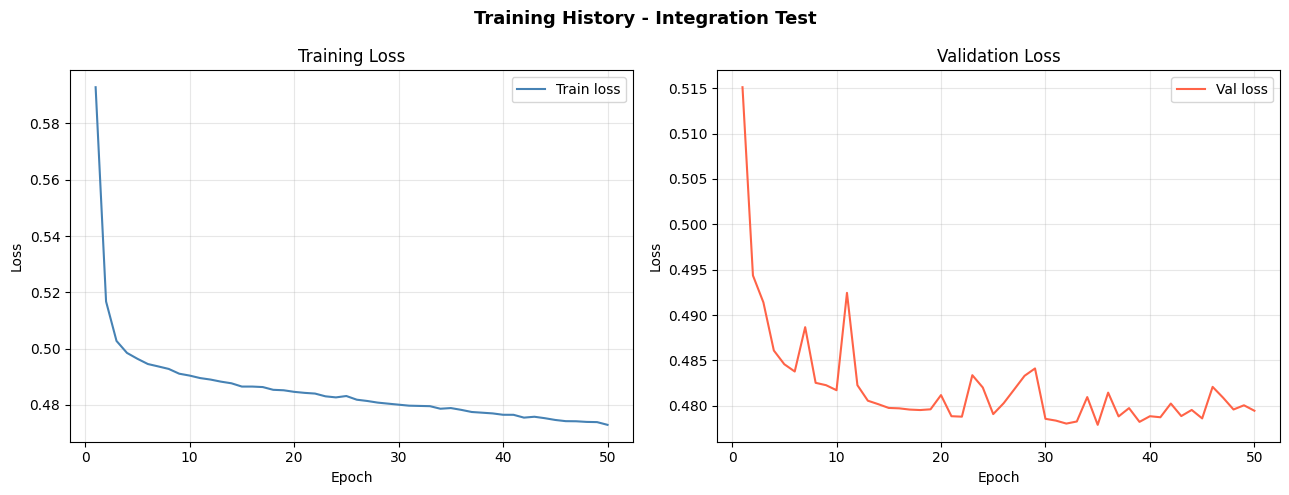

In [5]:
viz = Visualizer()
history = model.get_training_history()
viz.plot_loss_curve(history, title='Training History - Integration Test')

### 2. Plot Weight Distribution

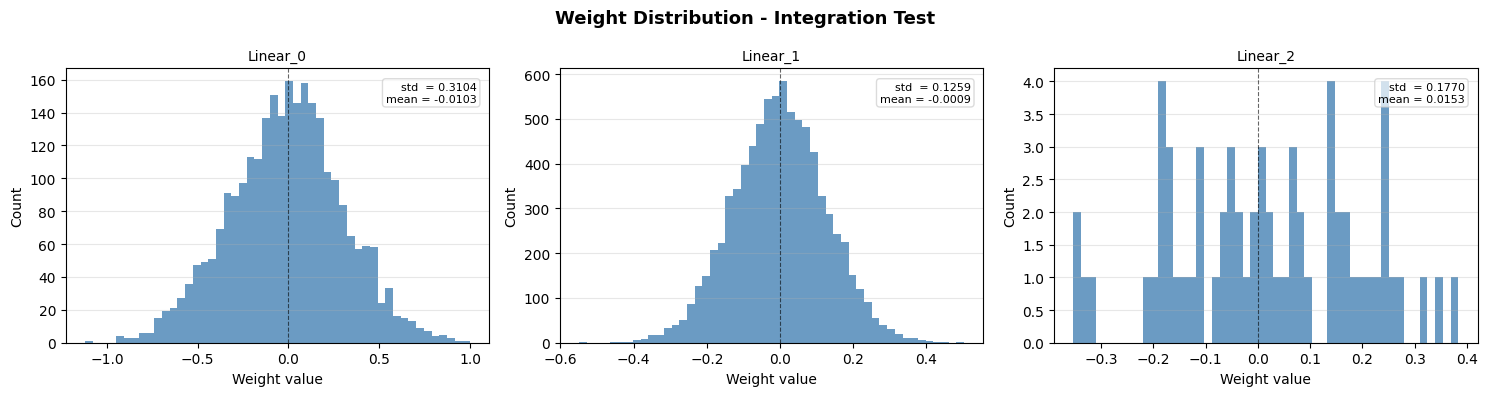

In [6]:
weights = model.get_weight_distribution()
viz.plot_weight_distribution(
    weight_dict = weights,
    title       = 'Weight Distribution - Integration Test'
)

### 3. Plot Gradient Distribution

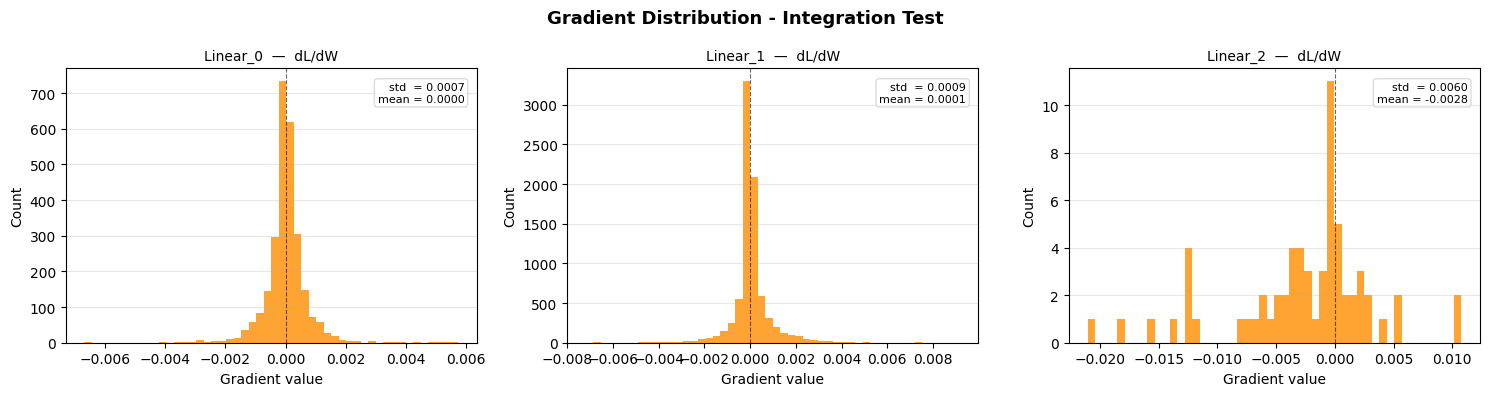

In [7]:
y_pred_viz = model.forward(X_test)
model.backward(y_pred_viz, y_test.reshape(-1, 1))

grads = model.get_gradient_distribution()
viz.plot_gradient_distribution(
    grad_dict = grads,
    title     = 'Gradient Distribution - Integration Test'
)

## Prediction 

In [8]:
y_pred  = model.predict(X_test)
test_acc = float(np.mean(y_pred == y_test.ravel()))
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.6575


## Save Model

In [9]:
os.makedirs('../results', exist_ok=True)
model.save('../results/integration_test_model.npz')

[FFNN] Model tersimpan di '../results/integration_test_model.npz' (3 linear layer)


## Verifikasi Load Model